# Potentials with JAX and PyTorch

This notebook describes how to use galpy's potentials with
[JAX](https://docs.jax.dev/) and [PyTorch](https://pytorch.org/): evaluating
them on backend arrays, taking derivatives with respect to the coordinates
and the parameters, compiling and vectorizing with `jax.jit` and `jax.vmap`,
running on a GPU, and writing a new potential that works with every backend.
See the [quick start](../getting_started/backends.ipynb) for how galpy chooses a backend.

In [1]:
%matplotlib inline
import time

import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
import torch

from galpy.potential import (
    MiyamotoNagaiPotential,
    MWPotential2014,
    PlummerPotential,
    evaluateDensities,
    evaluatePotentials,
    evaluateR2derivs,
    evaluateRforces,
    evaluatezforces,
    vcirc,
)

## Evaluating potentials on backend arrays

All of galpy's potentials can be evaluated on JAX arrays and PyTorch
tensors, through the functions that act on lists of potentials and through
the methods of a single potential, and return arrays of the same kind (the
exceptions are the potentials that read N-body snapshots with `pynbody` and
the `AMUSE` interface). The adiabatic-contraction wrapper is evaluated on
backend arrays and is differentiable with respect to the coordinates, but
it is constructed with NumPy, so it is not differentiable with respect to
the parameters of the potentials that it wraps. Python numbers and NumPy arrays passed alongside a
backend array, such as `z=0.2` below, are converted to the same backend:

In [2]:
R = jnp.linspace(0.1, 2.0, 5)
print(type(evaluatePotentials(MWPotential2014, R, 0.2)))
print(evaluatePotentials(MWPotential2014, R, 0.2))
print(evaluateDensities(MWPotential2014, R, 0.2))
print(MWPotential2014[2].Rforce(R, 0.2))

<class 'jaxlib._jax.ArrayImpl'>
[-2.45790006 -1.78428045 -1.27750993 -0.95163328 -0.7231266 ]


[0.57470838 0.10438332 0.04100395 0.02097354 0.01235951]


[-0.2353554  -0.40036915 -0.3332143  -0.27600257 -0.23231775]


In [3]:
Rt = torch.linspace(0.1, 2.0, 5, dtype=torch.float64)
print(type(evaluatePotentials(MWPotential2014, Rt, 0.2)))
print(evaluatePotentials(MWPotential2014, Rt, 0.2))
print(evaluateDensities(MWPotential2014, Rt, 0.2))

<class 'torch.Tensor'>
tensor([-2.4579, -1.7843, -1.2775, -0.9516, -0.7231], dtype=torch.float64)
tensor([0.5747, 0.1044, 0.0410, 0.0210, 0.0124], dtype=torch.float64)


The results are those of the NumPy path to within rounding error:

In [4]:
Rn = numpy.linspace(0.1, 2.0, 5)
print(
    numpy.max(
        numpy.fabs(
            numpy.asarray(evaluateDensities(MWPotential2014, R, 0.2))
            / evaluateDensities(MWPotential2014, Rn, 0.2)
            - 1.0
        )
    )
)

2.220446049250313e-16


galpy computes in double precision. For a single-precision PyTorch tensor,
galpy computes internally in double precision and returns a
single-precision result:

In [5]:
print(evaluatePotentials(MWPotential2014, torch.linspace(0.1, 2.0, 5), 0.2).dtype)

torch.float32


## Derivatives with respect to the coordinates

The forces and second derivatives of galpy's potentials are implemented by
hand, but on a backend they can also be obtained by differentiating the
potential. The two agree to rounding error. With JAX, we compute the
gradient and the Hessian of the potential at a set of points with
`jax.grad`, `jax.hessian`, and `jax.vmap`, compiled with `jax.jit`:

In [6]:
def Phi(R, z):
    return evaluatePotentials(MWPotential2014, R, z)


z = jnp.full(5, 0.2)
dPhidR, dPhidz = jax.jit(jax.vmap(jax.grad(Phi, argnums=(0, 1))))(R, z)
d2PhidR2 = jax.jit(jax.vmap(jax.hessian(Phi, argnums=0)))(R, z)
print("F_R:", numpy.max(numpy.fabs(-dPhidR - evaluateRforces(MWPotential2014, R, z))))
print("F_z:", numpy.max(numpy.fabs(-dPhidz - evaluatezforces(MWPotential2014, R, z))))
print(
    "d2Phi/dR2:",
    numpy.max(numpy.fabs(d2PhidR2 - evaluateR2derivs(MWPotential2014, R, z))),
)

F_R: 9.992007221626409e-16


F_z: 2.6645352591003757e-15


d2Phi/dR2: 5.329070518200751e-15


With PyTorch, we use `torch.autograd.grad` (or `backward`) on tensors that
require a gradient:

In [7]:
Rt = torch.linspace(0.1, 2.0, 5, dtype=torch.float64, requires_grad=True)
zt = torch.full((5,), 0.2, dtype=torch.float64)
(dPhidRt,) = torch.autograd.grad(evaluatePotentials(MWPotential2014, Rt, zt).sum(), Rt)
print(
    "F_R:",
    torch.max(torch.abs(-dPhidRt - evaluateRforces(MWPotential2014, Rt.detach(), zt))),
)

F_R: tensor(6.6613e-16, dtype=torch.float64)


## Derivatives with respect to the parameters

A potential that is set up with a backend value for one of its parameters
is differentiable with respect to that parameter through all of its
methods. Inside a function that is differentiated with `jax.grad`, the
parameter is a JAX value, so the potential is simply set up inside the
function. For the radial force of a Miyamoto-Nagai disk as a function of its
scale length $a$:

In [8]:
def Rforce_of_a(a):
    mp = MiyamotoNagaiPotential(amp=1.0, a=a, b=0.3)
    return mp.Rforce(1.2, 0.1)


dFRda = jax.grad(Rforce_of_a)(0.5)
# analytic derivative
s = 0.5 + numpy.sqrt(0.1**2 + 0.3**2)
print(dFRda, 3.0 * 1.2 * s * (1.2**2 + s**2) ** -2.5)

0.4564051442677299 0.4564051442677299


With PyTorch, give the parameter as a tensor that requires a gradient and
call `backward`:

In [9]:
a = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
mp = MiyamotoNagaiPotential(amp=1.0, a=a, b=0.3)
mp.Rforce(torch.tensor(1.2, dtype=torch.float64), 0.1).backward()
print(a.grad)

tensor(0.4564, dtype=torch.float64)


A parameter given as a backend value has no units and is in galpy's natural
units. Parameters can also be set through `normalize=`, which is
differentiable as well (the rotation-curve examples below use it).

As a small application, we recover the scale radius of a Plummer potential
from its radial force measured at a set of points. We fit the model to the
measurements with Gauss-Newton iterations, which need the derivative of the
model force at each point with respect to $b$; we compute it with
`jax.jacfwd` and compile each iteration with `jax.jit`. Starting from
$b=1.5$, the fit converges to the true value $b=0.85$ in a handful of
iterations. The left panel shows the measured force (points) and the model
force at the first iterations of the fit:

Iteration 0: b = 1.500000000000, loss = 6.114e-01


Iteration 1: b = 0.339677180639, loss = 3.303e+00
Iteration 2: b = 0.693924105956, loss = 1.513e-01
Iteration 3: b = 0.827087891204, loss = 2.461e-03
Iteration 4: b = 0.849468958077, loss = 1.262e-06
Iteration 5: b = 0.849999711809, loss = 3.714e-13
Iteration 6: b = 0.850000000000, loss = 3.224e-26
Iteration 7: b = 0.850000000000, loss = 4.131e-33


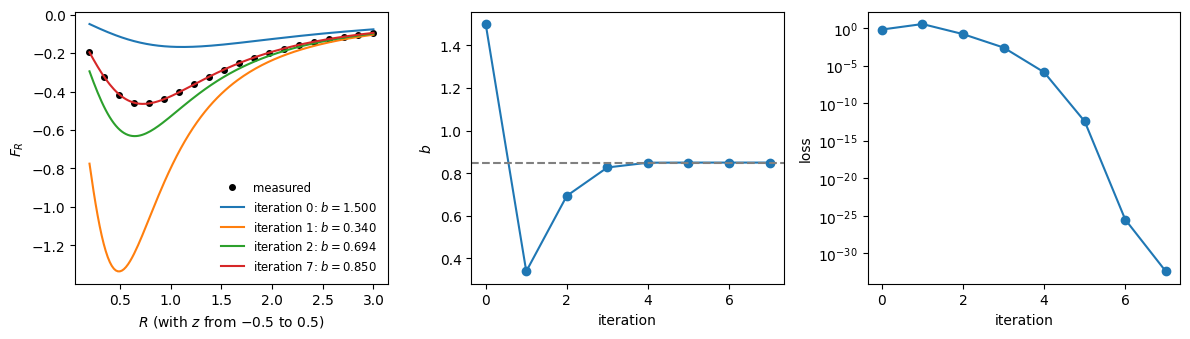

In [10]:
Rd = jnp.linspace(0.2, 3.0, 20)
zd = jnp.linspace(-0.5, 0.5, 20)
FR_obs = PlummerPotential(amp=1.0, b=0.85).Rforce(Rd, zd)


def residuals(b):
    return PlummerPotential(amp=1.0, b=b).Rforce(Rd, zd) - FR_obs


@jax.jit
def gauss_newton_step(b):
    r = residuals(b)
    J = jax.jacfwd(residuals)(b)
    return b - jnp.dot(J, r) / jnp.dot(J, J), jnp.sum(r**2)


b = 1.5
bs, losses = [], []
for ii in range(8):
    b_next, loss = gauss_newton_step(b)
    print(f"Iteration {ii}: b = {b:.12f}, loss = {loss:.3e}")
    bs.append(b)
    losses.append(loss)
    b = b_next
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3.5))
Rfine = jnp.linspace(0.2, 3.0, 141)
zfine = jnp.linspace(-0.5, 0.5, 141)
ax0.plot(Rd, FR_obs, "ko", ms=4, label="measured")
for ii in [0, 1, 2, len(bs) - 1]:
    ax0.plot(
        Rfine,
        PlummerPotential(amp=1.0, b=bs[ii]).Rforce(Rfine, zfine),
        label=f"iteration {ii}: $b = {bs[ii]:.3f}$",
    )
ax0.set_xlabel(r"$R$ (with $z$ from $-0.5$ to $0.5$)")
ax0.set_ylabel(r"$F_R$")
ax0.legend(frameon=False, fontsize="small")
ax1.plot(bs, "o-")
ax1.axhline(0.85, color="0.5", ls="--")
ax1.set_xlabel("iteration")
ax1.set_ylabel(r"$b$")
ax2.semilogy(losses, "o-")
ax2.set_xlabel("iteration")
ax2.set_ylabel("loss")
fig.tight_layout()

## Compiling and vectorizing with JAX

galpy does not compile anything itself, but its potentials can be part of a
function that you compile with `jax.jit`. The first call compiles the
function, after which calls are fast. Evaluating the radial force of
`MWPotential2014` at a million points:

In [11]:
@jax.jit
def FR_jit(R, z):
    return evaluateRforces(MWPotential2014, R, z)


Rb = jnp.linspace(0.1, 3.0, 10**6)
zb = jnp.linspace(-1.0, 1.0, 10**6)
start = time.perf_counter()
FR_jit(Rb, zb).block_until_ready()
print(f"First call (compiles): {time.perf_counter() - start:.2f} s")
start = time.perf_counter()
FR_jit(Rb, zb).block_until_ready()
print(f"Second call: {time.perf_counter() - start:.3f} s")
Rbn, zbn = numpy.asarray(Rb), numpy.asarray(zb)
start = time.perf_counter()
evaluateRforces(MWPotential2014, Rbn, zbn)
print(f"NumPy: {time.perf_counter() - start:.3f} s")

First call (compiles): 3.50 s


Second call: 0.330 s


NumPy: 0.653 s


Calling galpy with JAX arrays outside of `jax.jit` (in *eager* mode) works,
but every array operation is dispatched separately, which makes eager JAX
slow for complicated calculations. Compile the parts of your code that are
called repeatedly.

`jax.vmap` vectorizes a function over a batch axis, including over the
parameters of a potential. For example, the rotation curves of a set of
Miyamoto-Nagai disks with different scale lengths:

(8, 101)


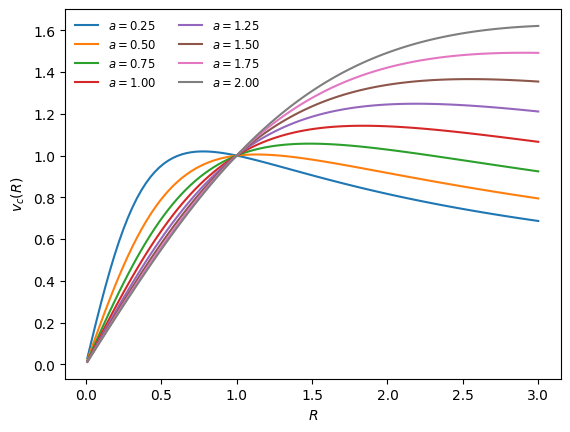

In [12]:
Rs = jnp.linspace(0.01, 3.0, 101)


def rotcurve(a):
    return vcirc(MiyamotoNagaiPotential(a=a, b=0.3, normalize=1.0), Rs)


As = jnp.linspace(0.25, 2.0, 8)
vcs = jax.vmap(rotcurve)(As)
print(vcs.shape)
for a, vc in zip(As, vcs):
    plt.plot(Rs, vc, label=rf"$a={a:.2f}$")
plt.xlabel(r"$R$")
plt.ylabel(r"$v_c(R)$")
plt.legend(frameon=False, fontsize="small", ncol=2);

Coordinates given as Python floats work as well. For example, the
derivative of the circular velocity at $R=2$ with respect to the scale
length of the disk, compared with a finite difference:

In [13]:
def vc_at_2(a):
    return vcirc(MiyamotoNagaiPotential(a=a, b=0.3, normalize=1.0), 2.0)


h = 1e-5
print(jax.grad(vc_at_2)(0.5), (vc_at_2(0.5 + h) - vc_at_2(0.5 - h)) / (2.0 * h))

0.4337256119499483 0.43372561192023257


## PyTorch's autograd and `torch.func`

Besides `backward` and `torch.autograd.grad`, galpy works with PyTorch's
functional transforms in `torch.func`, which are similar to JAX's:

In [14]:
from torch.func import grad, vmap

Rt = torch.linspace(0.1, 2.0, 5, dtype=torch.float64)
zt = torch.full((5,), 0.2, dtype=torch.float64)
dPhidRt = vmap(grad(lambda R, z: evaluatePotentials(MWPotential2014, R, z)))(Rt, zt)
print(torch.max(torch.abs(-dPhidRt - evaluateRforces(MWPotential2014, Rt, zt))))

tensor(6.6613e-16, dtype=torch.float64)


Functions that call galpy can also be compiled with `torch.compile`.
PyTorch's default compiler generates and compiles C++ (or GPU) code, which
takes tens of seconds for a call that involves `MWPotential2014`; on a CPU,
eager PyTorch is usually fast enough and compilation is most useful on a GPU.

## GPUs

galpy runs on a GPU when it is given arrays that live there; the constants
that galpy creates internally (expansion coefficients, quadrature nodes,
spline tables, ...) are placed on the device of the input. With PyTorch, put
the tensors on the GPU. The following code runs on a GPU if one is
available and on the CPU otherwise. The machine that executes these notebooks has no GPU, so the
output below shows the CPU; with a GPU, the same code runs there:

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
Rg = torch.linspace(0.1, 2.0, 5, dtype=torch.float64, device=device)
FRg = evaluateRforces(MWPotential2014, Rg, 0.2)
print(FRg.device)

cpu


JAX places arrays on its default device, which is the GPU when the
CUDA-enabled version of JAX is installed. Arrays can be moved explicitly with
`jax.device_put`:

In [16]:
print(jax.devices())
Rg = jax.device_put(jnp.linspace(0.1, 2.0, 5), jax.devices()[0])
print(evaluateRforces(MWPotential2014, Rg, 0.2).devices())

[CpuDevice(id=0)]


{CpuDevice(id=0)}


Transfers between the host and the GPU are slow compared to the
computation, so a GPU is most useful when the data stay on the device across
many operations, for example inside a compiled function.

## Writing a new potential for every backend

A new potential is written as before, as a class that inherits from
`Potential` and implements `_evaluate`, `_Rforce`, and `_zforce` (see the
[tutorial on new potentials](../extending/new_potential_python.ipynb)). To
make it work with every backend, use the array namespace of the coordinates,
obtained with `galpy.backend.get_namespace`, instead of `numpy`. The
namespace is `numpy` for NumPy inputs, `jax.numpy` for JAX arrays, and an
array-API-compatible version of `torch` for tensors. As an example, a
Miyamoto-Nagai disk:

In [17]:
from galpy.backend import get_namespace
from galpy.potential import Potential


class MNLikePotential(Potential):
    # a Miyamoto-Nagai disk written for every backend
    def __init__(self, amp=1.0, a=1.0, b=0.1, normalize=False):
        Potential.__init__(self, amp=amp)
        self._a = a
        self._b2 = b**2
        if normalize:
            self.normalize(normalize)

    def _evaluate(self, R, z, phi=0.0, t=0.0):
        xp = get_namespace(R, z)
        s = self._a + xp.sqrt(z**2 + self._b2)
        return -1.0 / xp.sqrt(R**2 + s**2)

    def _Rforce(self, R, z, phi=0.0, t=0.0):
        xp = get_namespace(R, z)
        s = self._a + xp.sqrt(z**2 + self._b2)
        return -R * (R**2 + s**2) ** -1.5

    def _zforce(self, R, z, phi=0.0, t=0.0):
        xp = get_namespace(R, z)
        sqb = xp.sqrt(z**2 + self._b2)
        s = self._a + sqb
        return -z * s / sqb * (R**2 + s**2) ** -1.5

The new class works with NumPy, JAX, and PyTorch inputs and agrees with
galpy's own `MiyamotoNagaiPotential`:

In [18]:
mnl = MNLikePotential(a=0.5, b=0.3, normalize=1.0)
mn = MiyamotoNagaiPotential(a=0.5, b=0.3, normalize=1.0)
Rn, zn = numpy.array([0.5, 1.0, 2.0]), numpy.array([0.1, -0.3, 1.0])
for Rin, zin in [
    (Rn, zn),
    (jnp.asarray(Rn), jnp.asarray(zn)),
    (torch.as_tensor(Rn), torch.as_tensor(zn)),
]:
    FR = mnl.Rforce(Rin, zin)
    print(
        type(FR).__name__, numpy.max(numpy.fabs(numpy.asarray(FR) - mn.Rforce(Rn, zn)))
    )

ndarray 2.220446049250313e-16


ArrayImpl 2.220446049250313e-16
Tensor 2.220446049250313e-16


and it is differentiable with respect to its parameters without any further
work:

In [19]:
print(jax.grad(lambda a: MNLikePotential(a=a, b=0.3).Rforce(1.2, 0.1))(0.5))
print(jax.grad(lambda a: MiyamotoNagaiPotential(a=a, b=0.3).Rforce(1.2, 0.1))(0.5))

0.4564051442677298
0.4564051442677299


The new potential can also be used to integrate orbits in JAX or PyTorch and
those orbits can be differentiated with respect to its parameters (see the
[orbits notebook](../orbits/backends.ipynb)).

A few things to keep in mind when writing a potential for the backends:

* Use the namespace `xp` for all array functions (`xp.sqrt`, `xp.exp`,
  `xp.where`, ...), never `numpy` directly. galpy's own potentials use
  `galpy.util.special` and `galpy.backend` for special functions, root
  finding, and quadrature, which work with every backend.
* Do not branch in Python on the value of an array or a parameter (`if
  self._a == 0.0:`); such a branch fails when the parameter is traced by
  `jax.jit` or `jax.grad`. Use `xp.where` instead, making sure that both
  branches evaluate to finite values, because a `nan` in the branch that is
  not selected still leads to a `nan` derivative.
* Keep the constants that the potential stores as Python floats or as arrays
  of the backend in use.